In [ ]:
import jax.numpy as jnp
import jax.scipy as jsp
import numpy as np
import jax
import jax.random as jr
import arviz as az
import jax.scipy.special as jss
from functools import partial
# Import the custom package you generated
from Better_HMC import HMCSampler 
import matplotlib.pyplot as plt
jax.config.update("jax_enable_x64", True)

dimensions         = (40, 40)          
fourier_dimensions = (60, 60)
length = jnp.array([0.5, 0.5])
fourier_length     = length * jnp.array(fourier_dimensions) / jnp.array(dimensions)
num_data = 400
noise_magnitude_on_each_point = 0.1

num_fitting_params = 2
hardcoded_logvar = 0
fixed_logscale = 0
hardcoded_lognu = jnp.log(0.5)
initial_logvar = 0.0
initial_lognu= 0.0

num_integration_steps = 200
step_size = 0.002

num_overall_steps = 10
burn_in = 100

def matern_spectral_density_2D(omega, params):
    log_var, log_nu = params
    log_scale = fixed_logscale
    ell = jnp.exp(log_scale)
    nu  = jnp.exp(log_nu)
    # x = omega^2 ell^2 / (2 nu); log1p keeps this exact as nu -> inf (SE limit)
    x = (omega * ell) ** 2 / (2.0 * nu)
    log_S = log_var + jnp.log(2.0 * jnp.pi) + 2.0 * log_scale \
            - (nu + 1.0) * jnp.log1p(x)
    return jnp.exp(log_S)



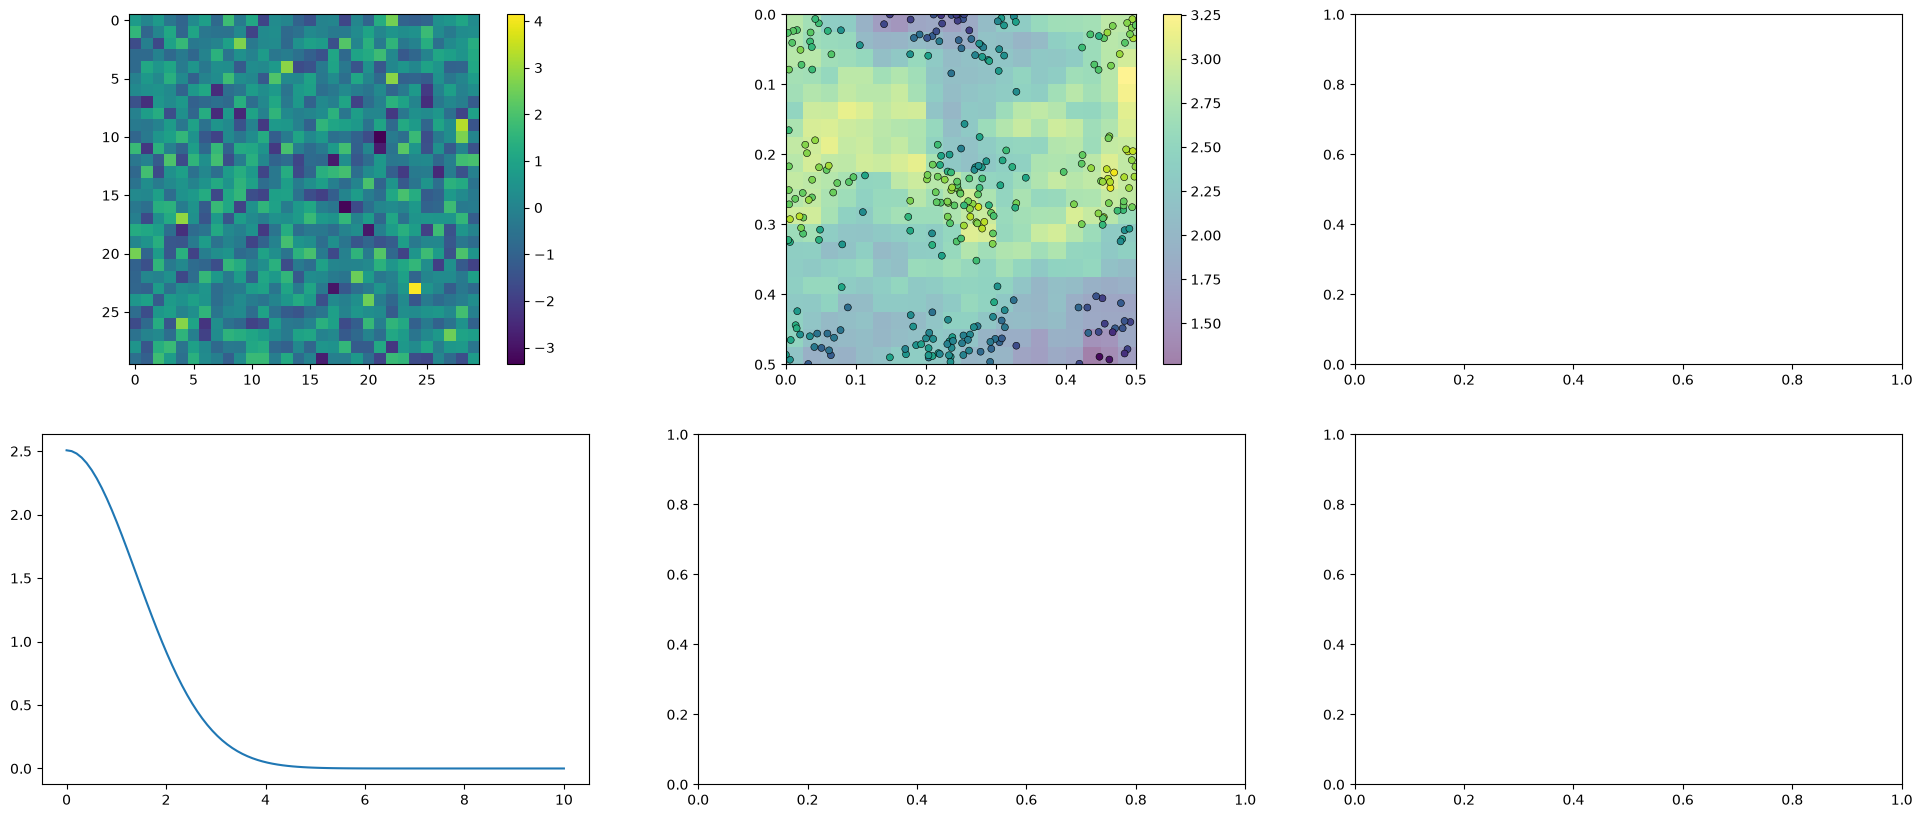

In [ ]:
from jax.scipy.ndimage import map_coordinates
# Draw Data 
def cdf(x):
    return x + jnp.sin(4 * jnp.pi * x) / (4 * jnp.pi)

def pdf(x):
    return 1 + jnp.cos(4 * jnp.pi * x)

@partial(jax.jit, static_argnames=("n", "iters"))
def sample(key, n, iters=8):
    u = jr.uniform(key, (n,))
    x = u  # good initial guess since CDF(x) ≈ x on average
    for _ in range(iters):
        x = x - (cdf(x) - u) / pdf(x)   # Newton's method
        x = jnp.clip(x, 0.0, 1.0)
    return x

diagonal_values = jnp.ones(num_data)*noise_magnitude_on_each_point**2
cov_data_matrix = jnp.diag(diagonal_values)
inv_cov_data_matrix = jnp.linalg.inv(cov_data_matrix)


def fft_field_hartley_2d(noise, inference_params):
    omegas_x = 2*jnp.pi*jnp.fft.fftfreq(fourier_dimensions[0], d = fourier_length[0]/fourier_dimensions[0])
    omegas_y = 2*jnp.pi*jnp.fft.fftfreq(fourier_dimensions[1], d = fourier_length[1]/fourier_dimensions[1])
    O_y, O_x = jnp.meshgrid(omegas_x, omegas_y, indexing = "ij")
    O_mag = jnp.sqrt(O_y**2 + O_x**2)
    spectral_density = matern_spectral_density_2D(O_mag, inference_params)
    raw_average_amplitude_data = jnp.sqrt(spectral_density)
    H = noise*raw_average_amplitude_data   
    y_data = hartley2(H)/jnp.sqrt(fourier_length[1]*fourier_length[0])
    return y_data[:dimensions[0]:, :dimensions[1]]

def hartley2(x):
    X = jnp.fft.fft2(x)
    return jnp.real(X) - jnp.imag(X)

rng = jr.PRNGKey(1)
rng, k1, k2, k3, k4 = jr.split(rng, 5)

xi = jr.normal(k1, shape = (fourier_dimensions[0], fourier_dimensions[1]))
field = fft_field_hartley_2d(xi, (hardcoded_logvar, hardcoded_lognu))

data_x_coords = sample(k2, num_data)*dimensions[1] 
data_y_coords = sample(k3, num_data)*dimensions[0] 
noise_on_data = jr.normal(k4, shape = data_x_coords.shape)*noise_magnitude_on_each_point
data_true_values = map_coordinates(field, jnp.stack([data_y_coords - 0.5, data_x_coords - 0.5]), order=1, mode="nearest")
data_values = data_true_values + noise_on_data


fig, axes = plt.subplots(2, 3, figsize = (24, 10))
im = axes[0][0].imshow(xi)
fig.colorbar(im, ax=axes[0][0])

vmin, vmax = float(field.min()), float(field.max())
im2 = axes[0][1].imshow(field, extent=[0, length[1], length[0], 0],
                        alpha=0.5, vmin=vmin, vmax=vmax)
axes[0][1].scatter(data_x_coords/dimensions[1]*length[1],
                   data_y_coords/dimensions[0]*length[0],
                   c=data_values, cmap="viridis", vmin=vmin, vmax=vmax,
                   s=25, edgecolor="k", linewidth=0.4)
fig.colorbar(im2, ax = axes[0][1])
linspace = jnp.linspace(0, 10, 100)
axes[1][0].plot(linspace, jnp.sqrt(matern_spectral_density_2D(linspace, (0.0, 5))))
plt.show()

In [ ]:
def logvarprior(logvar):
    return -logvar**2

def lognuprior(lognu):
    return -lognu**2

def response_function(xi_flat, inference_params):
    xi = xi_flat.reshape(fourier_dimensions[0], fourier_dimensions[1])
    field_values = fft_field_hartley_2d(xi, inference_params)
    return map_coordinates(field_values, jnp.stack([data_y_coords - 0.5, data_x_coords - 0.5]), order=1, mode="nearest")

def negative_logdensity(x):
    logvar = x[0]
    lognu = x[1]
    xi_flat = x[2:]
    res = response_function(xi_flat, (logvar, lognu)) - data_values
    logprior = -logvarprior(logvar) - lognuprior(lognu) + 0.5*xi_flat.T @ xi_flat
    log_p_data_given_field = 0.5 * res.T @ inv_cov_data_matrix @ res
    return logprior + log_p_data_given_field

initial_coordinates = jnp.zeros(fourier_dimensions[0]*fourier_dimensions[1] + num_fitting_params)
initial_coordinates = initial_coordinates.at[0].set(initial_logvar)
initial_coordinates = initial_coordinates.at[1].set(initial_lognu)



In [ ]:
num_good_samples = num_overall_steps - burn_in
time_arr = jnp.arange(num_good_samples)

#sampler = HMCSampler(
    #negative_logdensity= negative_logdensity,
    #num_integration_steps=num_integration_steps,
    #step_size=step_size,
    #inv_mass_matrix = jnp.eye(fourier_dimensions[0]*fourier_dimensions[1] + num_fitting_params),
    #alpha=1.0,
    #track_leapfrog_positions = True
#)

rng = jr.PRNGKey(5)

#overall_data_arr, overall_momentum_arr, accept_prob_arr, overall_exact_position_arr = sampler.sample(
    #start_position=initial_coordinates, 
    #num_samples=num_overall_steps,
    #burn_in = burn_in,
    #rng_key=rng,
#)

#print(overall_exact_position_arr.shape)
overall_data_arr = jnp.zeros(shape = (num_good_samples, fourier_dimensions[0]*fourier_dimensions[1] + num_fitting_params))
accept_prob_arr = jnp.zeros(shape = num_good_samples)
logvars = overall_data_arr[:, 0]
#print(logvars)
logscales = jnp.zeros_like(logvars)
lognus = overall_data_arr[:, 1]
overall_position_arr = overall_data_arr[:, 2:]  
overall_whitened_fields = overall_position_arr.reshape(-1, fourier_dimensions[0], fourier_dimensions[1])
overall_fields = jax.vmap(fft_field_hartley_2d, in_axes=(0, 0))(
    overall_whitened_fields,
    (logvars, lognus),                   
)   
inference_params = (logvars, lognus)


(900, 200, 902)


[ 0.00000000e+00  0.00000000e+00 -2.44523232e+05 -1.08509127e+03
 -3.05491451e+01 -2.51512690e+02 -1.13840777e+02 -6.98808380e+01
  7.91405256e+00 -2.61773046e+01 -2.01003041e+01  3.87885351e+00
 -1.09421807e+01 -5.31102270e+00  5.78755474e-01 -5.09307637e+00
 -1.23683065e+00 -2.04607631e-01 -3.85815021e+00 -6.59806452e-01
  8.20163093e-01 -5.41483367e+00  5.38139488e-01  2.14244800e+00
 -1.00382602e+01  1.16713769e+01 -9.26869894e+00 -2.51655053e+01
  1.86035920e+02 -4.93224937e+02  2.44082507e+01  3.51728419e+03
 -1.13709181e+03  8.24602031e+02 -9.90655334e+01 -1.35734358e+02
  1.26800856e+02 -2.10336113e+01 -1.47723681e+01  1.23279948e+01
 -6.43274317e+00  1.99109995e+00  4.03267573e+00 -1.54775729e+00
  3.32193388e+00  1.66875115e-01 -5.44545421e-01  8.41030351e-01
 -2.56918634e-01  1.09499557e+00 -6.52550445e-01 -9.28886304e-02
 -2.46582792e+00  2.15015370e+00 -3.19992186e+00 -1.35648060e+01
  7.37404464e+00 -1.78051207e+01 -6.17278529e+01 -4.39632153e+00
 -7.22186873e+01 -3.93550

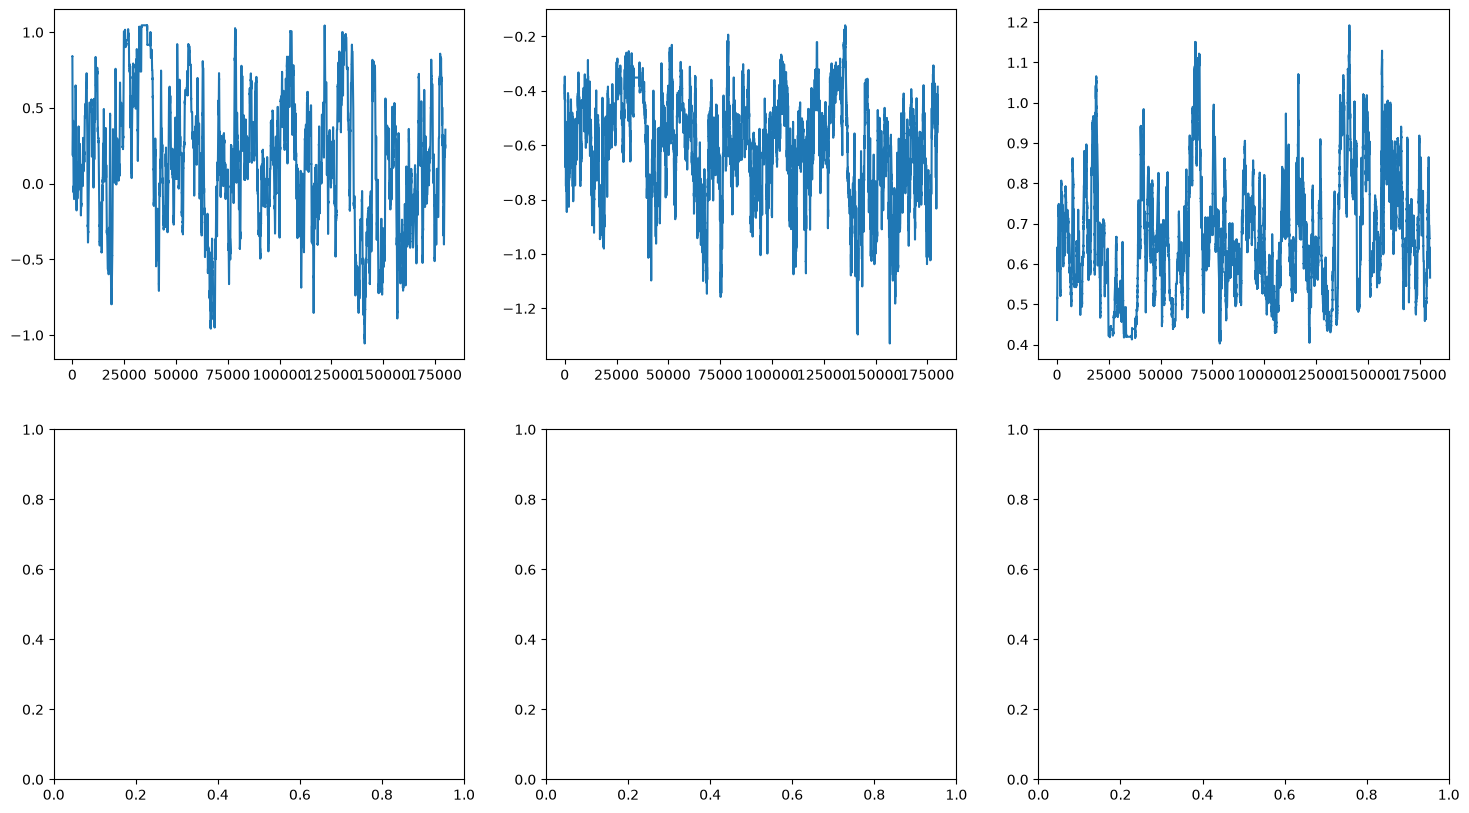

In [ ]:
print(jax.grad(negative_logdensity)(initial_coordinates))
logvar_trajectory = overall_exact_position_arr[:, :, 0].reshape(-1)
lognu_trajectory = overall_exact_position_arr[:, :, 1].reshape(-1)
first_pos_trajectory = overall_exact_position_arr[:, :, 2].reshape(-1)
fig, axes = plt.subplots(2, 3, figsize = (18, 10))
axes[0][0].plot(jnp.arange(logvar_trajectory.size), logvar_trajectory)
axes[0][1].plot(jnp.arange(logvar_trajectory.size), lognu_trajectory)
axes[0][2].plot(jnp.arange(logvar_trajectory.size), first_pos_trajectory)

In [ ]:
print(logvars.shape)
print(time_arr.shape)

(900,)
(900,)


ESS for variance: 42.57510577952304
KL_divergence with jitter 0.0011111111111111111 is 0.08014750559672737
Average acceptance probability (acceptance rate) is: 0.8101248270019403
Step size is: 0.002 Num integration steps is: 200
Logvar is 0 Logscale is 0 Lognu is -0.6931471805599453
Num dimensions: (20, 20) Num data: 300 Total length: [0.5 0.5] Fourier length: [0.75 0.75] Noise on each point: 0.1 Num HMC trials: 1000 Burn in: 100


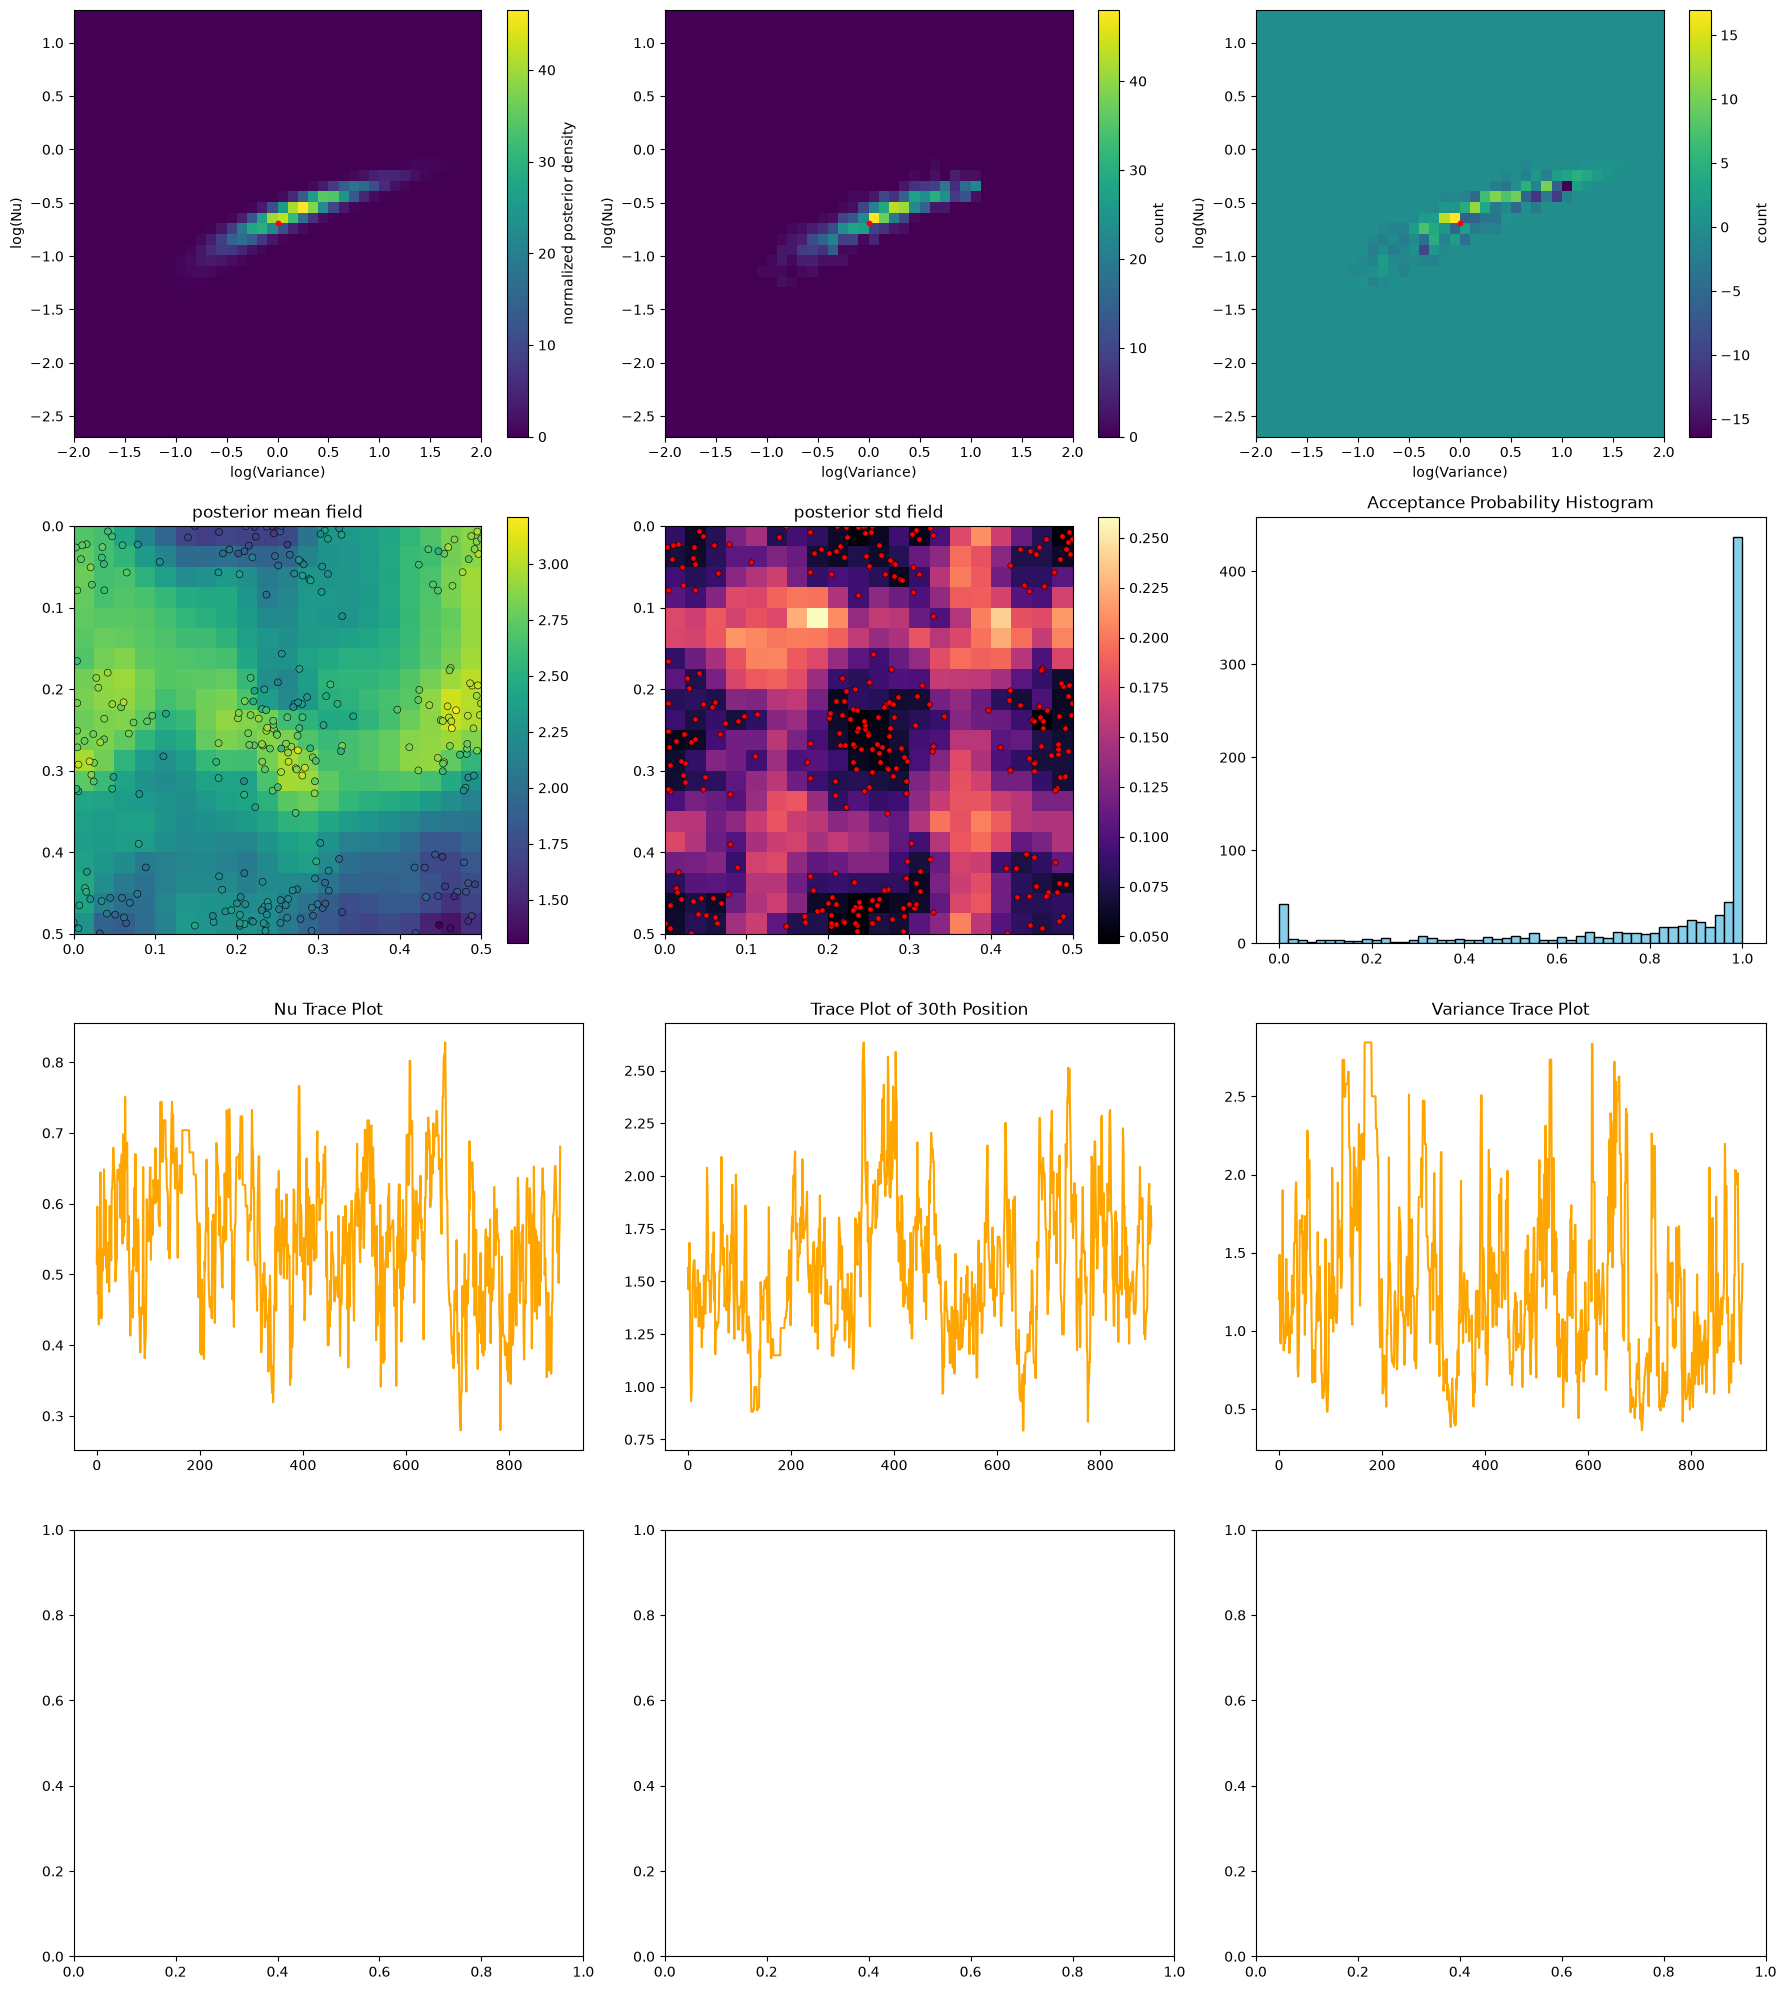

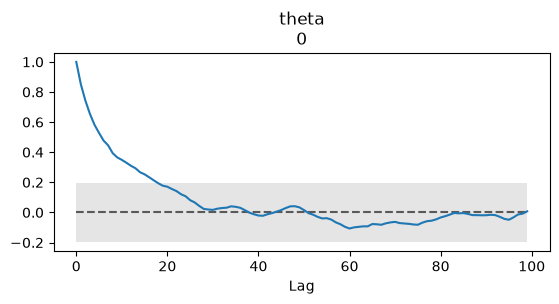

In [ ]:
fig, axes = plt.subplots(4, 3, figsize = (18, 20))

mean_field = overall_fields.mean(axis=0)   
std_field = overall_fields.std(axis = 0)
def log_posterior_density(inference_params):
    logvar, lognu = inference_params
    logprior = logvarprior(logvar) + lognuprior(lognu)
    R = jax.jacobian(lambda xi_flat: response_function(xi_flat, inference_params))(jnp.zeros(fourier_dimensions[0]*fourier_dimensions[1]))
    total_cov_on_data = R @ R.T + cov_data_matrix
    cho_factor = jsp.linalg.cho_factor(total_cov_on_data)
    solve_val = jsp.linalg.cho_solve(cho_factor, data_values)
    log_p_data_given_params = -0.5 * (data_values @ solve_val)
    logdet = 2.0 * jnp.sum(jnp.log(jnp.diag(cho_factor[0])))
    return log_p_data_given_params + logprior - 0.5 * logdet 

number_bins_x = 40
number_bins_y = 40
x_min, x_max = hardcoded_logvar - 2, hardcoded_logvar + 2
y_min, y_max = hardcoded_lognu - 2, hardcoded_lognu + 2
dx = (x_max - x_min)/number_bins_x
dy = (y_max - y_min)/number_bins_y

x_centers = (jnp.arange(number_bins_x) + 0.5)*dx + x_min
y_centers = (jnp.arange(number_bins_y) + 0.5)*dy + y_min
x_edges = jnp.arange(number_bins_x + 1)*dx + x_min
y_edges = jnp.arange(number_bins_y + 1)*dy + y_min

X, Y = jnp.meshgrid(x_centers, y_centers, indexing='ij')

F = jax.jit(lambda lv, ln: log_posterior_density((lv, ln)))
Z_flat = jax.lax.map(lambda pair: F(pair[0], pair[1]), (X.ravel(), Y.ravel()))

Z = Z_flat.reshape(X.shape) 
Z = jnp.exp(Z - jnp.max(Z))
expected_posterior_counts = Z*num_good_samples/jnp.sum(Z)

im = axes[0][0].imshow(
    expected_posterior_counts.T,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im, ax=axes[0][0], label='normalized posterior density')

H_HMC_samples, _, _ = jnp.histogram2d(logvars, lognus, bins=[x_edges, y_edges])

im2 = axes[0][1].imshow(
    H_HMC_samples.T,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im2, ax=axes[0][1], label='count')

im3 = axes[0][2].imshow(
    (expected_posterior_counts - H_HMC_samples).T,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    aspect='auto',
    cmap='viridis',
)
fig.colorbar(im3, ax=axes[0][2], label='count')

axes[0][0].scatter(hardcoded_logvar, hardcoded_lognu, color = 'red', s = 10, zorder = 3)
axes[0][1].scatter(hardcoded_logvar, hardcoded_lognu, color = 'red', s = 10, zorder = 3)
axes[0][2].scatter(hardcoded_logvar, hardcoded_lognu, color = 'red', s = 10, zorder = 3)
axes[0][0].set_xlabel("log(Variance)")
axes[0][0].set_ylabel("log(Nu)")
axes[0][1].set_xlabel("log(Variance)")
axes[0][1].set_ylabel("log(Nu)")
axes[0][2].set_xlabel("log(Variance)")
axes[0][2].set_ylabel("log(Nu)")
axes[2][2].plot(time_arr, jnp.exp(logvars), color = "Orange")
axes[2][2].set_title("Variance Trace Plot")
axes[2][0].plot(time_arr, jnp.exp(lognus), color = "Orange")
axes[2][0].set_title("Nu Trace Plot")
axes[2][1].plot(time_arr, overall_position_arr[:, 30], color = "Orange")
axes[2][1].set_title("Trace Plot of 30th Position")
axes[1][2].set_title("Acceptance Probability Histogram")
axes[1][2].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')


vmin = min(float(mean_field.min()), float(data_values.min()))
vmax = max(float(mean_field.max()), float(data_values.max()))

im_mean = axes[1][0].imshow(mean_field, extent=[0, length[1], length[0], 0],
                            cmap="viridis", vmin=vmin, vmax=vmax)
axes[1][0].scatter(data_x_coords/dimensions[1]*length[1],
                   data_y_coords/dimensions[0]*length[0],
                   c=data_values, cmap="viridis", vmin=vmin, vmax=vmax,
                   s=25, edgecolor="k", linewidth=0.4)
axes[1][0].set_title("posterior mean field")
fig.colorbar(im_mean, ax=axes[1][0])

im_std = axes[1][1].imshow(std_field, extent=[0, length[1], length[0], 0], cmap = "magma")
axes[1][1].scatter(data_x_coords/dimensions[1]*length[1],
                   data_y_coords/dimensions[0]*length[0],
                   c="red", s=15, edgecolor="k", linewidth=0.4)
axes[1][1].set_title("posterior std field")
fig.colorbar(im_std, ax=axes[1][1])



fig.tight_layout()

posterior_samples = overall_data_arr[np.newaxis, :, :]  # add chain axis -> (1, num_samples, 50)

idata = az.from_dict({"posterior": {"theta": posterior_samples}})
param_index = 0  # which of your 50 parameters you want

az.plot_autocorr(idata, var_names="theta", coords={"theta_dim_0": [param_index]})

ess_all = az.ess(idata, var_names="theta")  # a Dataset, ESS for all 50 parameters at once

ess_param = ess_all["theta"].sel(theta_dim_0=param_index).values
print(f"ESS for variance: {ess_param}")

def KL_divergence(expected_probs, observed_probs, jitter):
    usable_expected_probs = jnp.where(expected_probs == 0, jitter, expected_probs)
    usable_observed_probs = jnp.where(observed_probs == 0, jitter, observed_probs)
    KL_array = usable_expected_probs*(jnp.log(usable_expected_probs) - jnp.log(usable_observed_probs))
    return jnp.sum(KL_array)

expected_bin_prob = expected_posterior_counts/num_good_samples
observed_bin_prob = H_HMC_samples/num_good_samples
KL_jitter = 1/num_good_samples
print(f"KL_divergence with jitter {KL_jitter} is {KL_divergence(expected_bin_prob, observed_bin_prob, jitter = KL_jitter)}")
print(f"Average acceptance probability (acceptance rate) is: {jnp.average(accept_prob_arr)}")
print(f"Step size is: {step_size} Num integration steps is: {num_integration_steps}")
print(f"Logvar is {hardcoded_logvar} Logscale is {fixed_logscale} Lognu is {hardcoded_lognu}")
print(f"Num dimensions: {dimensions} Num data: {num_data} Total length: {length} Fourier length: {fourier_length} Noise on each point: {noise_magnitude_on_each_point} Num HMC trials: {num_overall_steps} Burn in: {burn_in}")